In [8]:
# Import necessary libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
import imutils # for convenient contour functions

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
def get_color_name(h, s, v):
    """
    Gets the name of a color based on its HSV values.
    OpenCV H range is 0-179, S is 0-255, V is 0-255.
    """
    # Check for low saturation or value (black, white, grey)
    if s < 70:
        return "White/Grey"
    if v < 70:
        return "Black"

    # Define color ranges in OpenCV's HSV space
    if h < 10 or h > 165:
        return "Red"
    if h >= 10 and h < 25:
        return "Orange"
    if h >= 25 and h < 35:
        return "Yellow"
    if h >= 35 and h < 85:
        return "Green"  # This range covers both lime green and dark green
    if h >= 85 and h < 130:
        return "Blue"
    if h >= 130 and h < 145:
        return "Violet/Purple"
    if h >= 145 and h < 165:
        return "Pink/Magenta"

    return "Unknown"

In [10]:
def get_shape_name(c):
    """
    Identifies the shape of a contour based on vertex approximation.
    """
    # Calculate the perimeter
    peri = cv2.arcLength(c, True)

    # Approximate the contour to a polygon with fewer vertices
    # 0.035 * peri is a good "epsilon" value for accuracy
    approx = cv2.approxPolyDP(c, 0.035 * peri, True)
    vertices = len(approx)

    shape = "Unidentified"

    if vertices == 3:
        shape = "Triangle"
    elif vertices == 4:
        # A square and a diamond (rhombus) both have 4 vertices.
        # For this simple project, we'll group them.
        shape = "Square / Diamond"
    elif vertices == 10:
        # A 5-pointed star has 10 vertices (5 outer, 5 inner)
        shape = "Star"
    elif vertices > 7:
        # A circle will be approximated with many vertices
        shape = "Circle"
    else:
        # The heart shape is complex and ends up with
        # around 7-8 vertices. We'll set it as the "else" case.
        shape = "Heart"

    return shape

In [11]:
print("Please upload your image...")
uploaded = files.upload()

if not uploaded:
  raise Exception("No file was uploaded. Please run the cell again.")

# Get the filename of the first uploaded file
filename = list(uploaded.keys())[0]
print(f"Successfully uploaded: {filename}")

Please upload your image...


Saving input.jpg to input (1).jpg
Successfully uploaded: input (1).jpg


Thresholded (black & white) image:


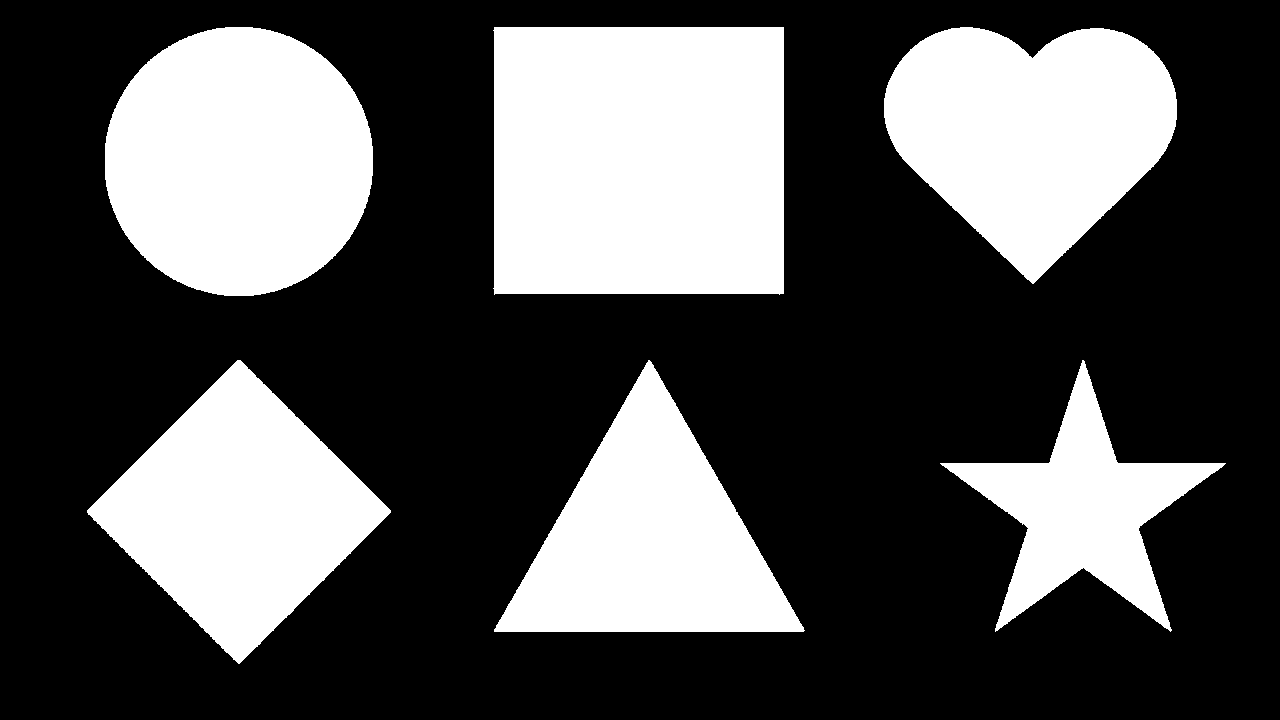


Found 6 shapes.

--- Final Processed Image ---


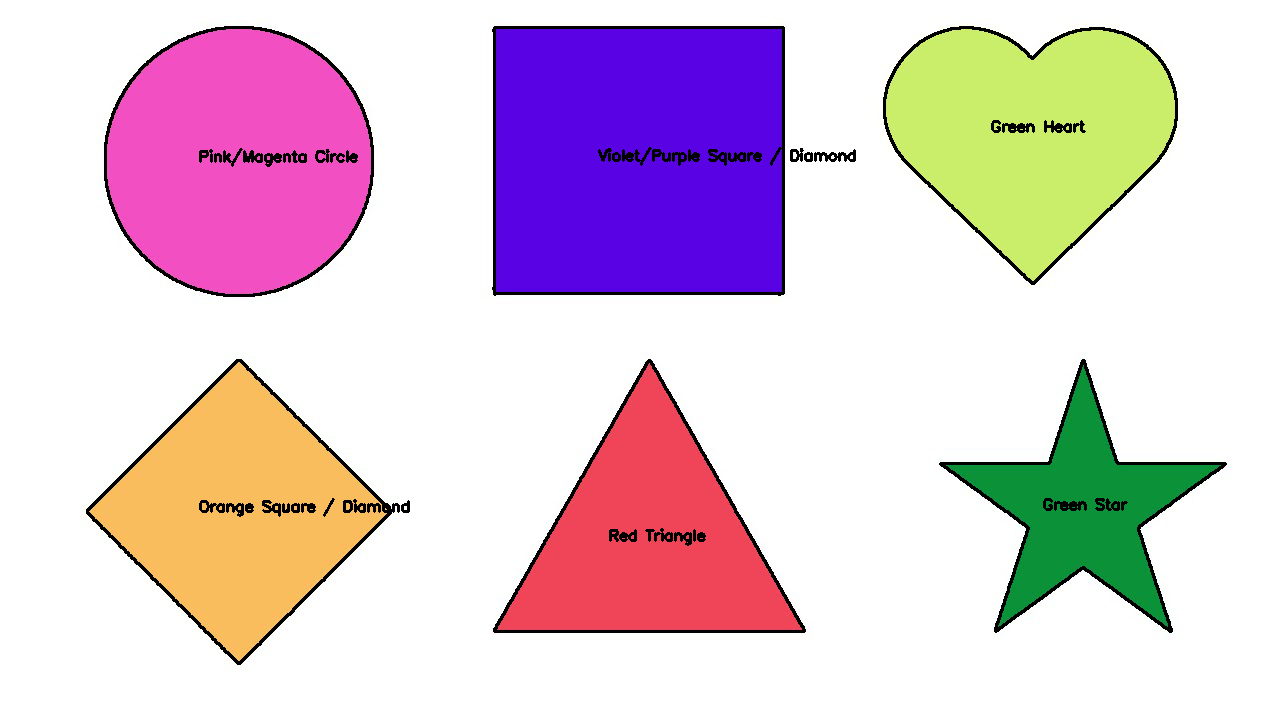

In [12]:
# 1. Load the image
file_bytes = np.frombuffer(uploaded[filename], np.uint8)
image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
output_image = image.copy() # We'll draw on this one

# 2. Convert to HSV and Grayscale
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Threshold the image
# The image has a white background (255), so we threshold at a high value.
# THRESH_BINARY_INV inverts it: shapes become white (255) and background black (0).
ret, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

print("Thresholded (black & white) image:")
cv2_imshow(thresh)

# 4. Find Contours
# RETR_EXTERNAL finds only the outer-most contours (perfect for these shapes)
# CHAIN_APPROX_SIMPLE saves memory by only storing the corner points
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"\nFound {len(contours)} shapes.")

# 5. Loop through each contour
for c in contours:
    # Skip small contours that might be noise
    if cv2.contourArea(c) < 100:
        continue

    # --- Find Center Point ---
    # We use "moments" to find the center of mass
    M = cv2.moments(c)
    if M["m00"] == 0: continue # Avoid division by zero
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])

    # --- Get Color ---
    # Get the H, S, V values of the center pixel
    h, s, v = hsv[cY, cX]
    color_name = get_color_name(h, s, v)

    # --- Get Shape ---
    shape_name = get_shape_name(c)

    # --- Draw on the output image ---
    label = f"{color_name} {shape_name}"

    # Draw the contour outline in black
    cv2.drawContours(output_image, [c], -1, (0, 0, 0), 2)

    # Write the label text near the center
    # (Adjusting cX-40 to center the text)
    cv2.putText(output_image, label, (cX - 40, cY),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)


# 6. Display the final result
print("\n--- Final Processed Image ---")
cv2_imshow(output_image)